# Trusted Health Data  
## Proyecto de Gobernanza y Calidad de Datos

**Autora:** Ericka Valverde Navarro  
**Tipo de proyecto:** Portafolio profesional  
**Enfoque:** Gobernanza de datos, calidad, estandarización y análisis visual  

### Objetivo del proyecto
Aplicar principios de gobernanza de datos sobre un dataset global de salud, incluyendo perfilado, evaluación de calidad, estandarización, definición de reglas de negocio y generación de un dataset confiable para análisis.

### Dataset
Datos a nivel país con indicadores de salud global, incluyendo casos confirmados, muertes, recuperados, casos activos y clasificación por región de la OMS.

### Enfoque de gobernanza
- Evaluación de calidad de datos  
- Estandarización de estructuras  
- Definición de reglas de negocio  
- Documentación de datos  
- Generación de datos confiables para toma de decisiones  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

sns.set_style("whitegrid")

### 1. Ingesta de datos

En esta sección se carga el dataset original y se realiza una inspección inicial de su estructura.

In [2]:
# Ruta del archivo
file_path = Path("../data/raw/country_wise_latest.csv")

# Carga del dataset
df = pd.read_csv(file_path)

# Vista inicial
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


### 2. Perfilado inicial de datos

Se analiza la estructura del dataset para entender:

- Tipos de datos  
- Cantidad de registros y columnas  
- Valores nulos  
- Duplicados  
- Estadísticas descriptivas  

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [4]:
df.describe()

c:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [5]:
df.isnull().sum().sort_values(ascending=False)

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### 3. Evaluación de la calidad de datos

Se evalúa el dataset bajo dimensiones clave de calidad:

- Completitud  
- Unicidad  
- Consistencia  
- Validez  

Esto permite identificar posibles problemas antes de utilizar los datos para análisis.

In [7]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "missing_values": df.isnull().sum().values,
    "missing_percentage": ((df.isnull().sum().values / len(df)) * 100).round(2),
    "unique_values": df.nunique().values,
    "data_type": df.dtypes.values
})

quality_summary.sort_values(by="missing_percentage", ascending=False)

,column,missing_values,missing_percentage,unique_values,data_type
0,Country/Region,0,0.0,187,object
1,Confirmed,0,0.0,184,int64
2,Deaths,0,0.0,150,int64
3,Recovered,0,0.0,178,int64
4,Active,0,0.0,173,int64
5,New cases,0,0.0,122,int64
6,New deaths,0,0.0,38,int64
7,New recovered,0,0.0,103,int64
8,Deaths / 100 Cases,0,0.0,145,float64
9,Recovered / 100 Cases,0,0.0,177,float64


### 4. Estandarización de datos

Se aplican transformaciones para mejorar la calidad y consistencia:

- Normalización de nombres de columnas  
- Conversión a formato uniforme (snake_case)  
- Eliminación de caracteres especiales  

Esto facilita el uso del dataset en procesos analíticos y pipelines.

In [8]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_clean.columns.tolist()

['country_region',
 'confirmed',
 'deaths',
 'recovered',
 'active',
 'new_cases',
 'new_deaths',
 'new_recovered',
 'deaths___100_cases',
 'recovered___100_cases',
 'deaths___100_recovered',
 'confirmed_last_week',
 '1_week_change',
 '1_week_%_increase',
 'who_region']

### 5. Validación de reglas de negocio

Se definen reglas básicas de gobernanza para validar la coherencia de los datos:

1. Los casos confirmados deben ser mayores o iguales a las muertes  
2. Los casos confirmados deben ser mayores o iguales a los recuperados  
3. Los casos activos no deben ser negativos  
4. La región de la OMS debe existir en todos los registros  

Estas reglas permiten detectar inconsistencias lógicas en el dataset.

In [9]:
rule_1 = (df_clean["confirmed"] >= df_clean["deaths"]).all()
rule_2 = (df_clean["confirmed"] >= df_clean["recovered"]).all()
rule_3 = (df_clean["active"] >= 0).all()
rule_4 = df_clean["who_region"].notna().all()

rules_results = pd.DataFrame({
    "rule": [
        "confirmed >= deaths",
        "confirmed >= recovered",
        "active >= 0",
        "who_region is not null"
    ],
    "passed": [rule_1, rule_2, rule_3, rule_4]
})

rules_results

,rule,passed
0,confirmed >= deaths,True
1,confirmed >= recovered,True
2,active >= 0,True
3,who_region is not null,True


In [10]:
invalid_confirmed_deaths = df_clean[df_clean["confirmed"] < df_clean["deaths"]]
invalid_confirmed_recovered = df_clean[df_clean["confirmed"] < df_clean["recovered"]]
invalid_active = df_clean[df_clean["active"] < 0]

len(invalid_confirmed_deaths), len(invalid_confirmed_recovered), len(invalid_active)

(0, 0, 0)

### 6. Generación del dataset confiable

Una vez realizadas las validaciones y transformaciones, se genera una versión procesada del dataset.

Este dataset representa una fuente más confiable para análisis y visualización.

In [11]:
output_path = Path("../data/processed/trusted_country_health_data.csv")
df_clean.to_csv(output_path, index=False)

print(f"Archivo guardado en: {output_path}")

Archivo guardado en: ..\data\processed\trusted_country_health_data.csv


### 7. Análisis y visualización de datos

Se utilizan los datos ya gobernados para generar visualizaciones que permitan:

- Identificar tendencias  
- Comparar países  
- Analizar distribución por región  
- Explorar relaciones entre variables  

Las visualizaciones se construyen sobre datos confiables, lo cual mejora la calidad de los insights.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

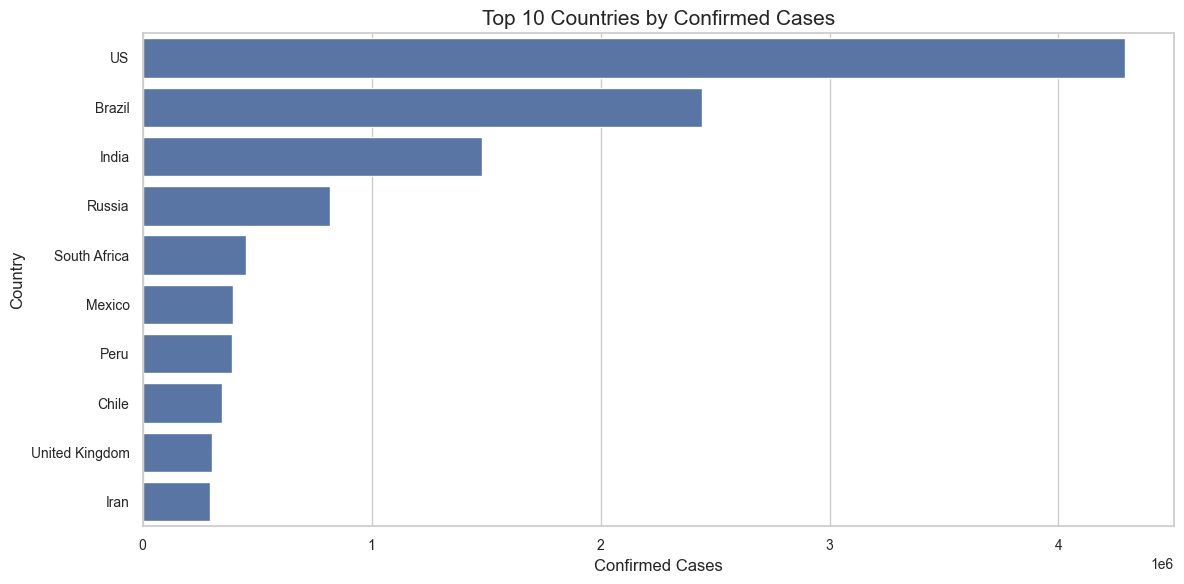

In [23]:
top_confirmed = df_clean.sort_values(by="confirmed", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_confirmed, y="country_region", x="confirmed")
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

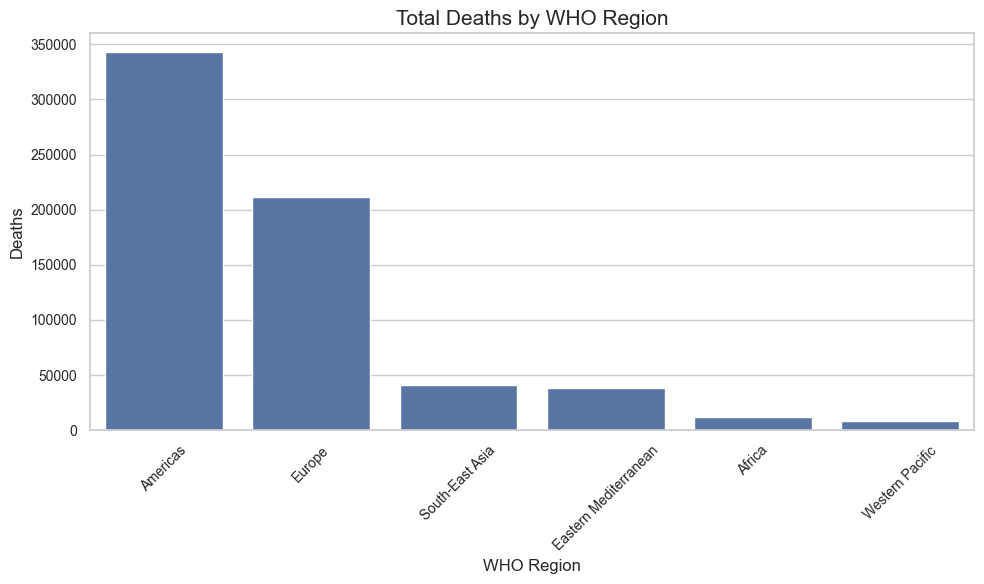

In [24]:
deaths_by_region = (
    df_clean.groupby("who_region", as_index=False)["deaths"]
    .sum()
    .sort_values(by="deaths", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=deaths_by_region, x="who_region", y="deaths")
plt.title("Total Deaths by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

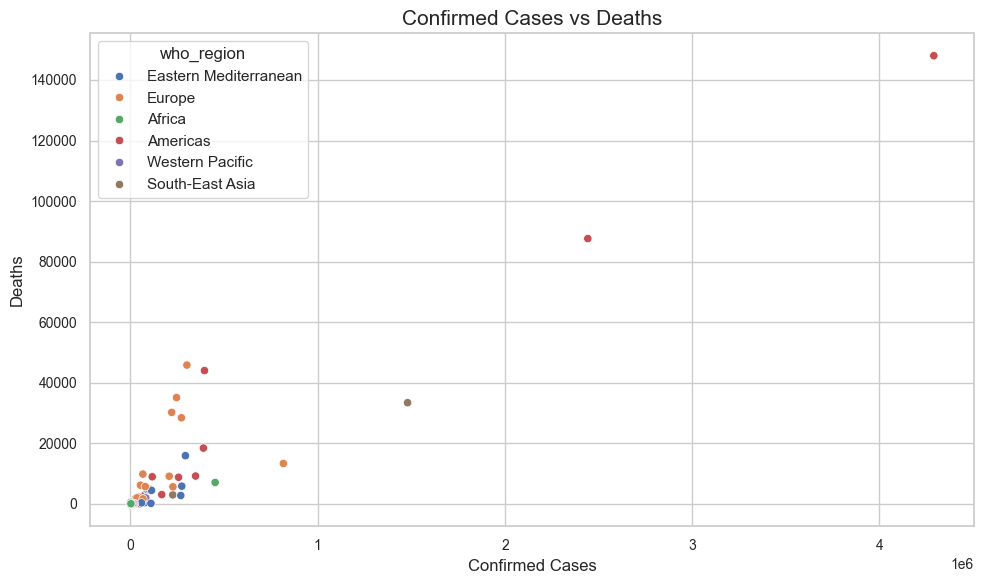

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="confirmed", y="deaths", hue="who_region")
plt.title("Confirmed Cases vs Deaths")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.tight_layout()
plt.show()

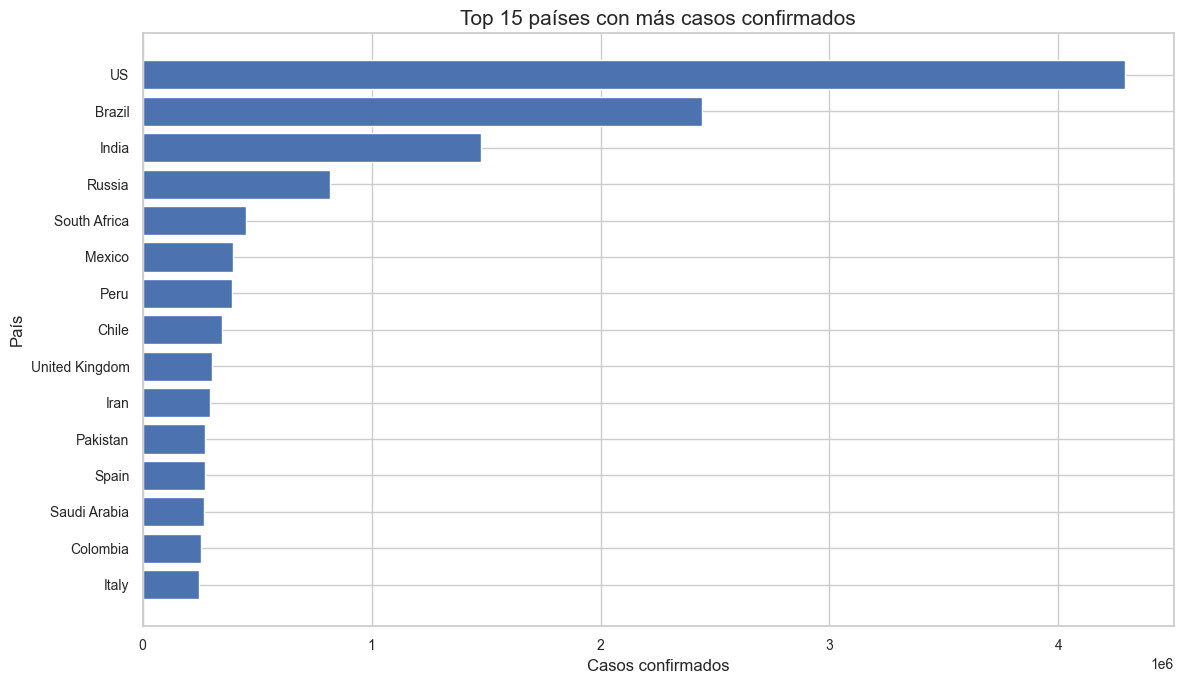

In [26]:
top_confirmed = df_clean.sort_values(by="confirmed", ascending=False).head(15)

plt.figure(figsize=(12, 7))
plt.barh(top_confirmed["country_region"], top_confirmed["confirmed"])
plt.gca().invert_yaxis()
plt.title("Top 15 países con más casos confirmados")
plt.xlabel("Casos confirmados")
plt.ylabel("País")
plt.tight_layout()
plt.show()

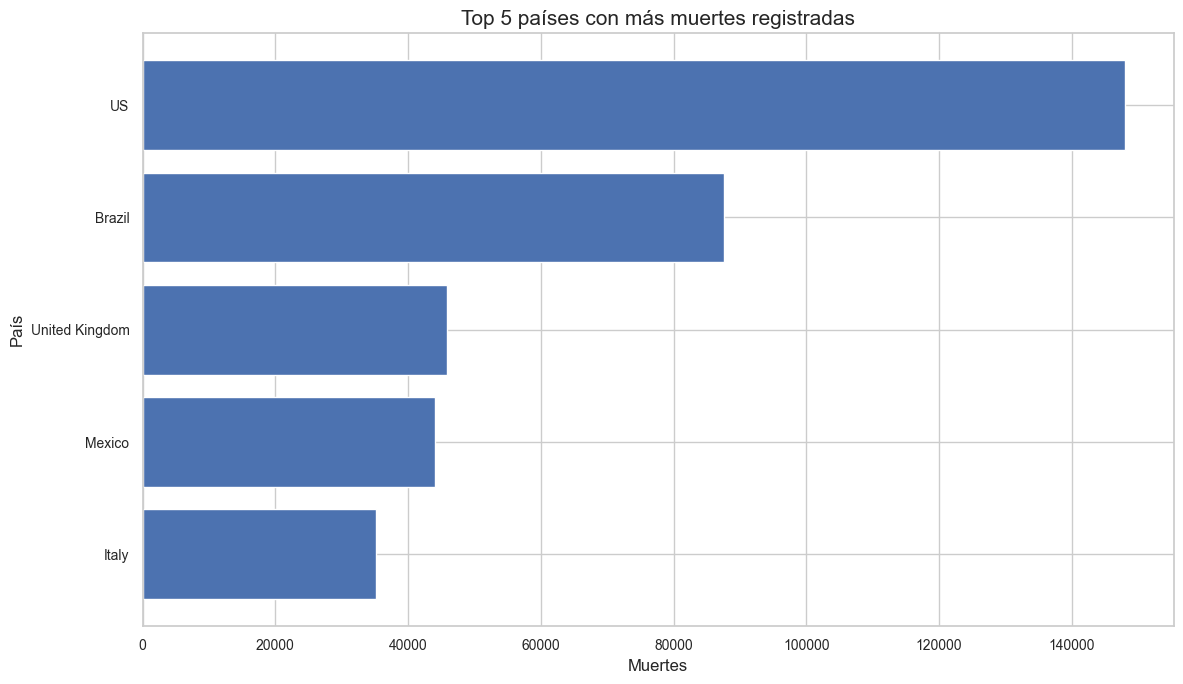

In [27]:
top_deaths = df_clean.sort_values(by="deaths", ascending=False).head(5)

plt.figure(figsize=(12, 7))
plt.barh(top_deaths["country_region"], top_deaths["deaths"])
plt.gca().invert_yaxis()
plt.title("Top 5 países con más muertes registradas")
plt.xlabel("Muertes")
plt.ylabel("País")
plt.tight_layout()
plt.show()

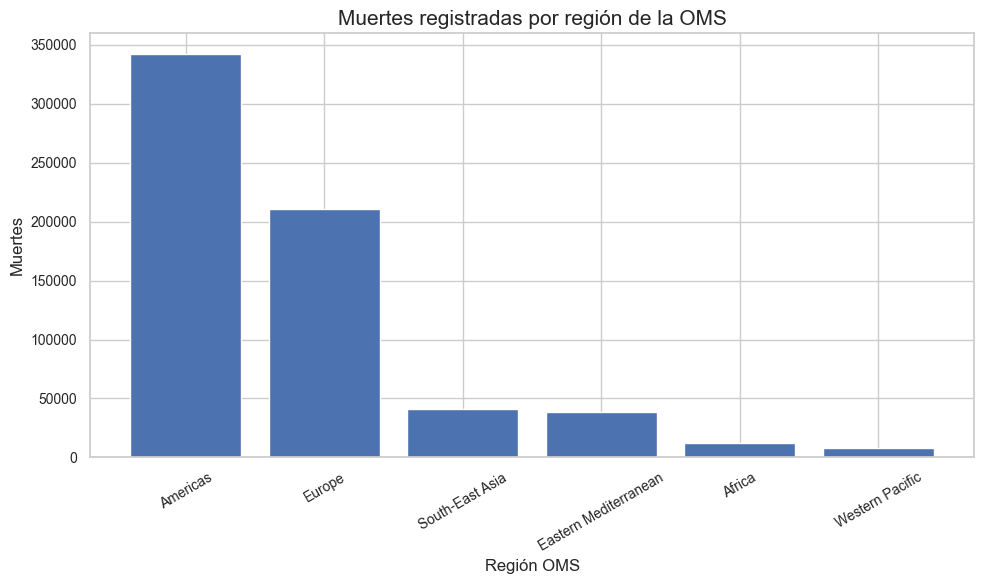

In [28]:
deaths_by_region = (
    df_clean.groupby("who_region", as_index=False)["deaths"]
    .sum()
    .sort_values(by="deaths", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(deaths_by_region["who_region"], deaths_by_region["deaths"])
plt.title("Muertes registradas por región de la OMS")
plt.xlabel("Región OMS")
plt.ylabel("Muertes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

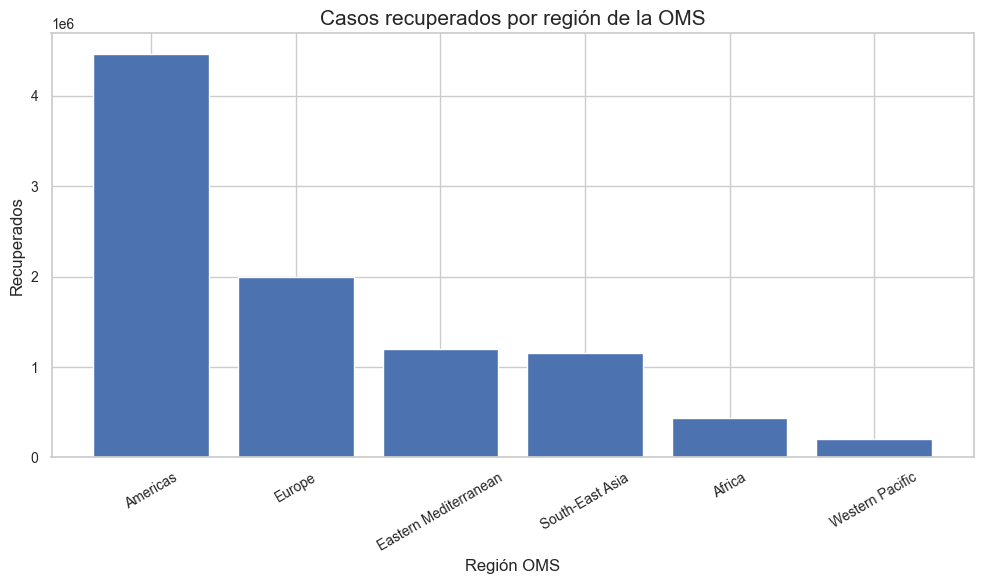

In [29]:
recovered_by_region = (
    df_clean.groupby("who_region", as_index=False)["recovered"]
    .sum()
    .sort_values(by="recovered", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(recovered_by_region["who_region"], recovered_by_region["recovered"])
plt.title("Casos recuperados por región de la OMS")
plt.xlabel("Región OMS")
plt.ylabel("Recuperados")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

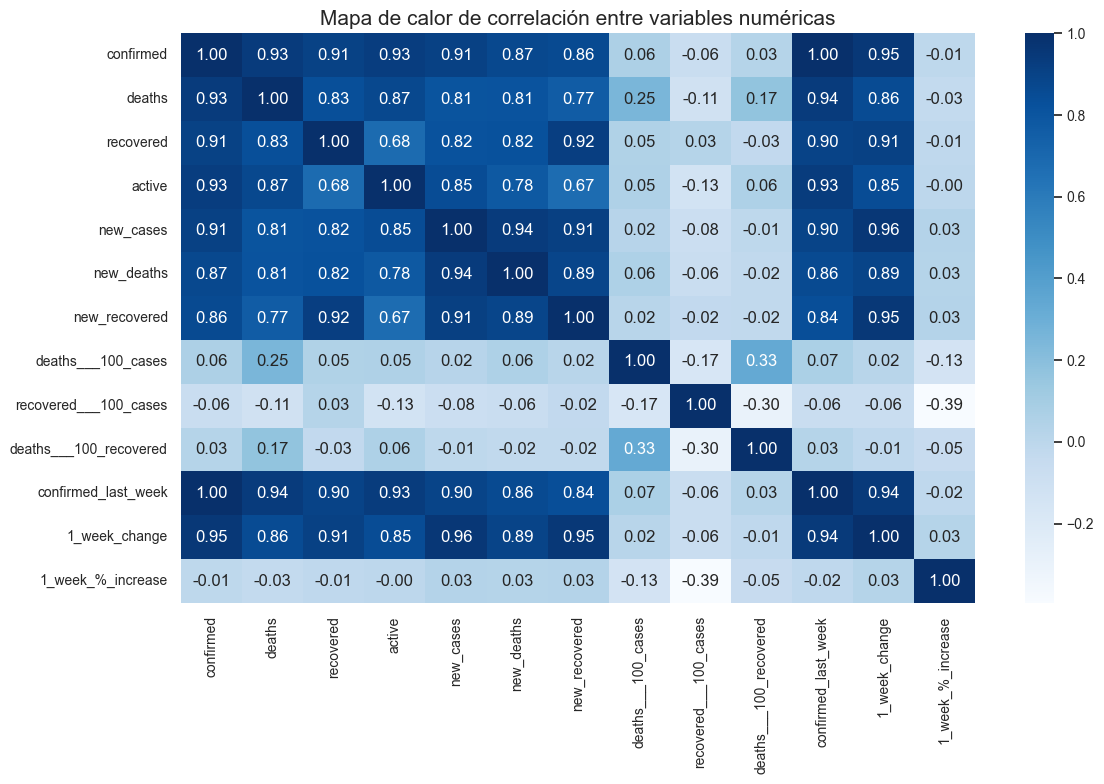

In [30]:
import seaborn as sns

numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

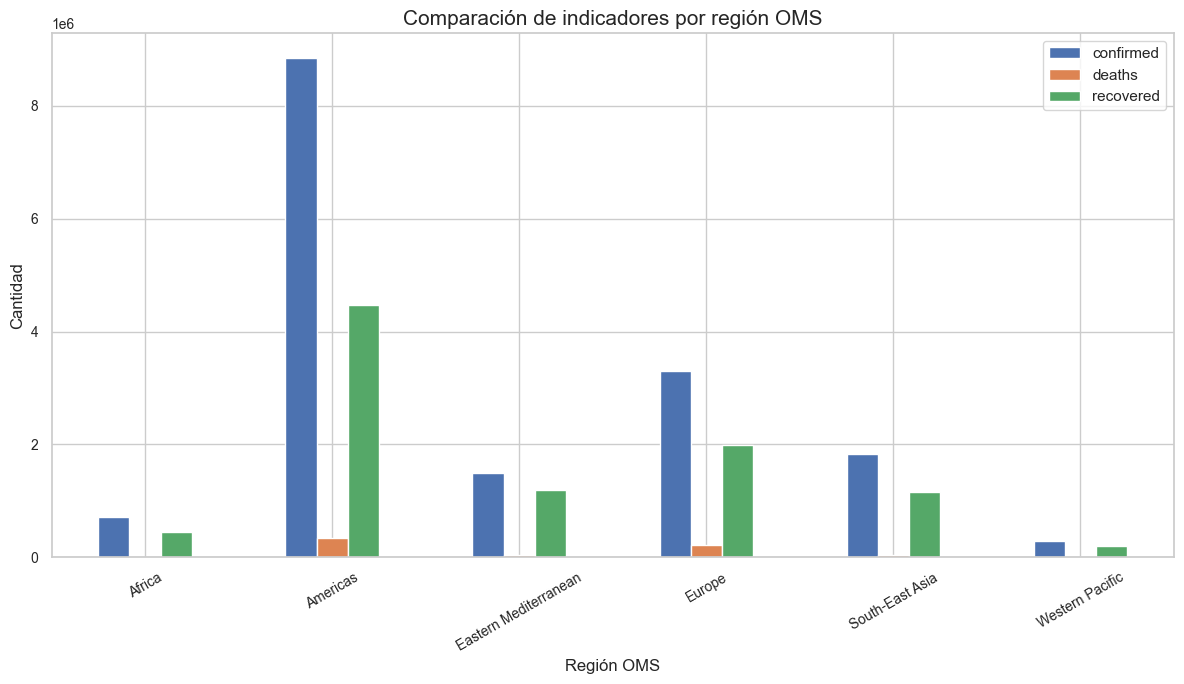

In [31]:
region_summary = df_clean.groupby("who_region")[["confirmed", "deaths", "recovered"]].sum()

region_summary.plot(kind="bar", figsize=(12, 7))
plt.title("Comparación de indicadores por región OMS")
plt.xlabel("Región OMS")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 8. Conclusiones

Este proyecto demuestra la importancia de aplicar gobernanza de datos antes de realizar análisis.

#### Principales resultados
- Se realizó un perfilado completo del dataset  
- Se identificaron problemas de calidad de datos  
- Se estandarizó la estructura del dataset  
- Se definieron y validaron reglas de negocio  
- Se generó un dataset confiable para análisis  

#### Valor de la gobernanza
La calidad de los análisis depende directamente de la calidad de los datos.  
Aplicar principios de gobernanza permite generar información más confiable, consistente y útil para la toma de decisiones.